[![View notebook](https://img.shields.io/static/v1?label=render%20on&logo=github&color=87ce3e&message=GitHub)](https://github.com/open-atmos-krk/ccnact/blob/main/examples/basics.ipynb) 
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/open-atmos-krk/ccnact/blob/main/examples/basics.ipynb) 
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/open-atmos-krk/ccnact.git/main?urlpath=lab/tree/examples/basics.ipynb)

The code below exemplifies a possible way of using `ccnact` to explore the dependence of activatied fraction and maximal supersaturation on updraft velocity. 

Note that the use of `SI` below is only meant for improving code readibility and handling SI-prefix conversions, there is no dimensional analysis of the arithmetics performed (this is the default mode of operation, see [package source](https://github.com/open-atmos-krk/ccnact/blob/main/ccnact.py) for tests which employ dimensional analysis).

In [1]:
import sys

if "google.colab" in sys.modules:
    !pip --quiet install ccnact open-atmos-jupyter-utils matplotlib

In [2]:
import time

import numpy as np
from matplotlib import pyplot
from open_atmos_jupyter_utils import show_plot

from ccnact import SI, parcel

In [3]:
wall_time = time.perf_counter()
cpu_time = time.process_time()

updraft = np.linspace(0.2, 10, 20) * SI.m / SI.s
n_act, s_max = np.empty_like(updraft), np.empty_like(updraft)

n_tot = 1e9 / SI.m**3
length_scale = 10 * SI.m
for i, w in enumerate(updraft):
    n_act[i], s_max[i] = parcel(
        MAC=1,
        n_bins=200,
        p=1013 * SI.hPa,
        T=300 * SI.K,
        RH=0.99,
        dt=(dt := length_scale / w),
        nt=100 * SI.m / length_scale,
        w=w,
        sigma=0.072,
        kappa=(1.2,),
        meanr=(3e-8 * SI.m,),
        gstdv=(1.5,),
        n_tot=(n_tot,),
    )

print(
    f"Wall: {(wall_time := time.perf_counter() - wall_time):.3f}s"
    " | "
    f"CPU: {(cpu_time := time.process_time() - cpu_time):.3f}s"
)

Wall: 9.045s | CPU: 34.645s


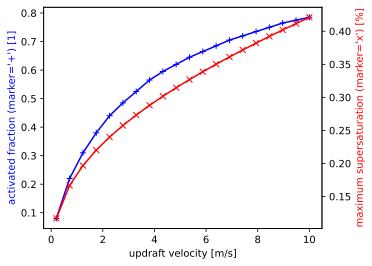

In [4]:
xy1 = pyplot.figure(figsize=(5, 4)).gca()
xy1.plot(updraft, n_act / n_tot, marker=(marker := "+"), color=(color := "blue"))
xy1.set_ylabel(f"activated fraction ({marker=}) [1]", color=color)
xy1.set_xlabel("updraft velocity [m/s]")

xy2 = xy1.twinx()
xy2.plot(updraft, (s_max - 1) * 100, marker=(marker := "x"), color=(color := "red"))
xy2.set_ylabel(f"maximum supersaturation ({marker=}) [%]", color=color)

show_plot("basics")